In [4]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sc.settings.verbosity = 0             # verbosity: errors (0), warnings (1), info (2), hints (3)

from scipy.stats import zscore, pearsonr
from statsmodels.stats.multitest import fdrcorrection

In [5]:
%cd /home/orimosko/projects/phago/downloaded/

/home/orimosko/projects/phago/downloaded


In [6]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')  # low dpi (dots per inch) yields small inline figures

scanpy==1.9.8 anndata==0.9.2 umap==0.5.6 numpy==1.24.4 scipy==1.10.1 pandas==2.0.3 scikit-learn==1.3.2 statsmodels==0.14.1 igraph==0.11.6 pynndescent==0.5.4


/opt/micromamba/envs/mosko_effero_py/lib/python3.8/site-packages/pynndescent/utils.py:202: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit(
/opt/micromamba/envs/mosko_effero_py/lib/python3.8/site-packages/pynndescent/utils.py:302: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit(


In [7]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

In [ ]:
adata = sc.read_h5ad("/mc_disk2/data/h5ads/phago/melanoma_UM_filtered.h5ad")

In [ ]:
# Keeps only the primary melanoma samples
adata = adata[adata.obs.Sample.str.len() < 7]

In [15]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell


/home/orimosko/.local/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


    finished (0:00:00)


In [16]:
sc.pp.highly_variable_genes(adata)

extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [17]:
sc.pp.pca(adata, use_highly_variable=True)

computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:01)


In [18]:
sc.external.pp.bbknn(adata, batch_key='Sample')

computing batch balanced neighbors


	finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:09)


In [19]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:20)


In [20]:
sc.tl.leiden(adata, resolution=0.5)

running Leiden clustering


    finished: found 9 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:25)


In [23]:
sc.tl.rank_genes_groups(adata, groupby='leiden')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


In [ ]:
annot_list = ['Melanoma cells', 'Melanoma cells',
              'Melanoma cells',
              'T cells',
              'Myeloid cells',
              'Melanoma cells', 
              'Melanoma cells',
              'Rentinal neural cells',
              'Retinal pigment epithelium']
adata.obs['annot'] = pd.Categorical([annot_list[int(i)] for i in adata.obs.leiden],
                                    categories=['Melanoma cells', 
                                                'Retinal pigment epithelium', 
                                                'Rentinal neural cells',
                                                'T cells', 
                                                'Myeloid cells'])

/home/orimosko/.local/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


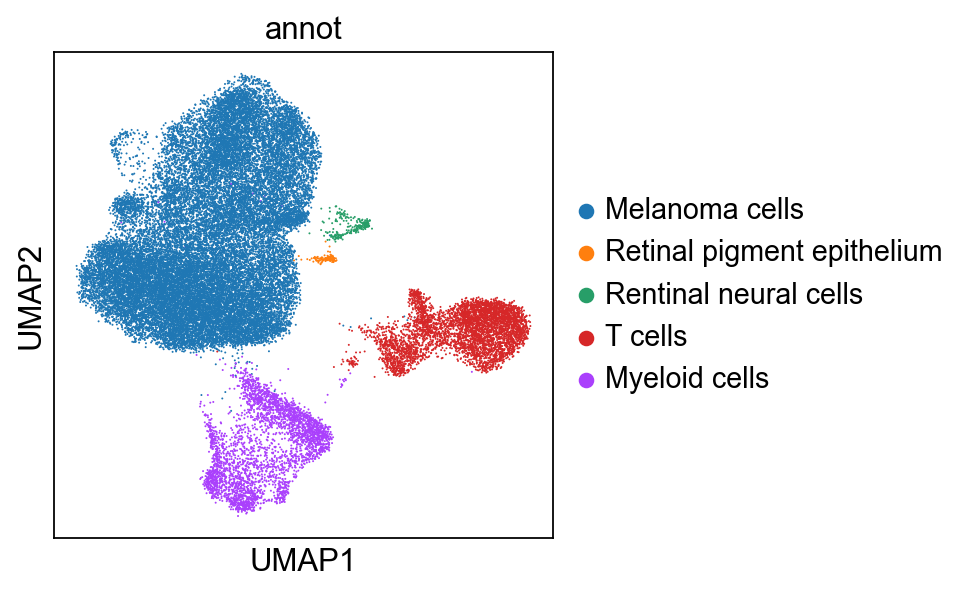

In [119]:
sc.pl.umap(adata, color='annot', save='_UM.pdf')

/home/orimosko/.local/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


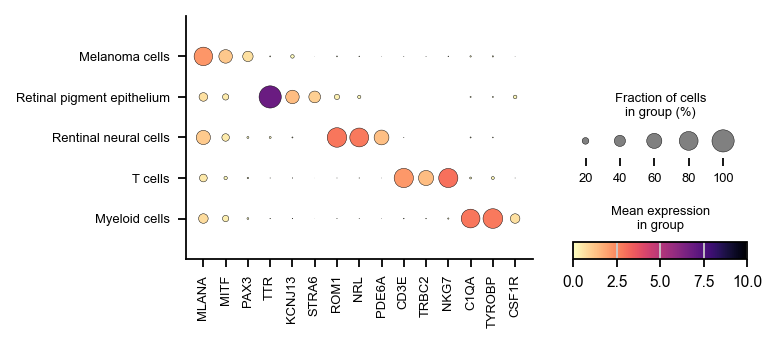

In [120]:
dot = sc.pl.dotplot(
    adata,
    ['MLANA', 'MITF', 'PAX3', 
     'TTR', 'KCNJ13', 'STRA6', 
     'ROM1', 'NRL', 'PDE6A',
     'CD3E', 'TRBC2', 'NKG7',
     'C1QA', 'TYROBP', 'CSF1R'], 
    groupby='annot',
    figsize=(4.5, 2),
    vmax=10,
    vmin=0,
    cmap="magma_r",
    return_fig=True 
)

fig = dot.get_axes()['mainplot_ax'].get_figure()

# Hide top and right spines for all axes
for ax in fig.axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
# Shrink main dots
for artist in dot.get_axes()['mainplot_ax'].collections:
    artist.set_sizes(artist.get_sizes() * 0.5)

# Shrink legend dots
for artist in dot.get_axes()['size_legend_ax'].collections:
    artist.set_sizes(artist.get_sizes() * 0.5)
    
for label in ax.get_xticklabels():
    label.set_fontsize(7)
for label in ax.get_yticklabels():
    label.set_fontsize(7)

fig.savefig('UM_figures/dotplothuman_UM.pdf')

In [103]:
macdata = adata[adata.obs.leiden == "4"].copy()

In [104]:
macdata

AnnData object with n_obs × n_vars = 3448 × 33694
    obs: 'Sample', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'count_scale', 'doublet_score', 'predicted_doublet', 'leiden', 'annot'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'Sample_colors', 'rank_genes_groups', 'dendrogram_leiden', 'annot_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [105]:
macdata.obs.Sample.value_counts()

Sample
UMM065    919
UMM066    825
UMM063    691
UMM064    342
UMM059    261
UMM061    221
UMM062    174
UMM069     15
Name: count, dtype: int64

In [106]:
sc.pp.highly_variable_genes(macdata)

In [107]:
sc.pp.pca(macdata, use_highly_variable=True)

In [108]:
sc.external.pp.bbknn(macdata, batch_key='Sample')

In [109]:
sc.tl.umap(macdata)

In [110]:
sc.tl.leiden(macdata, resolution=0.5)

In [112]:
sc.tl.rank_genes_groups(macdata, groupby='leiden')

In [114]:
annot_list = ['Macrophages', 'MonMacs', 'Monocytes']
macdata.obs['annot'] = pd.Categorical([annot_list[int(i)] for i in macdata.obs.leiden],
                                    categories=['Monocytes', 'MonMacs', 'Macrophages'])

/home/orimosko/.local/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


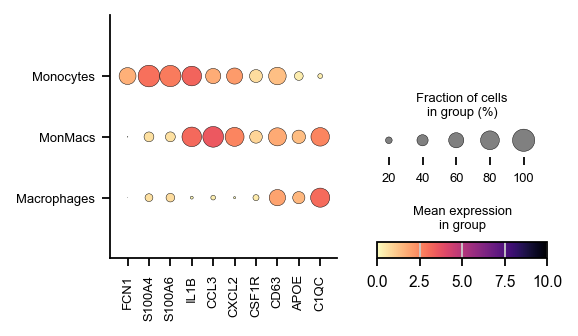

In [121]:
dot = sc.pl.dotplot(
    macdata,
    ['FCN1', 'S100A4', 'S100A6', 
     'IL1B', 'CCL3', 'CXCL2', 'CSF1R',
     'CD63', 'APOE', 'C1QC'],
    groupby='annot',
    figsize=(3.5, 2),
    vmax=10,
    vmin=0,
    cmap="magma_r",
    return_fig=True 
)

fig = dot.get_axes()['mainplot_ax'].get_figure()

# Hide top and right spines for all axes
for ax in fig.axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
# Shrink main dots
for artist in dot.get_axes()['mainplot_ax'].collections:
    artist.set_sizes(artist.get_sizes() * 0.5)

# Shrink legend dots
for artist in dot.get_axes()['size_legend_ax'].collections:
    artist.set_sizes(artist.get_sizes() * 0.5)
    
for label in ax.get_xticklabels():
    label.set_fontsize(7)
for label in ax.get_yticklabels():
    label.set_fontsize(7)

fig.savefig('UM_figures/dotplothuman_UM_macrophages.pdf')

In [92]:
macdata = macdata[macdata.obs.leiden == "0"].copy()

In [93]:
macdata.shape

(1741, 33694)

In [30]:
new_up_and_corr_genes_human = [
    "FTH1", "WFDC17", "CCL9", "FABP5", "CSTB", "MARCO", "CTSK", "CD63", "LGALS3",
    "LYZ", "ESD", "FTL", "CD68", "RNH1", "GPNMB", "MT1A", "CAPG", "TUBA1C",
    "CRIP1", "ACP5", "LGALS1", "SOD2", "CALM1", "CALR", "TMSB10", "GAPDH", "NME1",
    "SLC39A2", "MRPL52", "EMP3", "CLEC4D", "ANXA4", "CTSB", "TYMS", "CTSZ", "ANPEP",
    "TCEAL9", "MSR1", "MANF", "CCL17", "CYBA", "ATP5ME", "GLRX", "CD24", "ATP6V1C1",
    "TSPO", "CALM3", "PRDX1", "ATP5MJ", "CTSC", "ANXA5", "MT2A", "BCAP31", "HINT1",
    "VAT1", "ENO1", "PYCARD", "ALDOA", "CAV1", "GLA", "FABP4", "NQO2", "ATP6V0B",
    "MFGE8", "TIMM13"
]

In [33]:
for g in new_up_and_corr_genes:
    print(g)

NameError: name 'new_up_and_corr_genes' is not defined

In [268]:
sc.tl.score_genes(macdata, gene_list=new_up_and_corr_genes_human, score_name="effero_score", use_raw=False)

computing score 'effero_score'
    finished: added
    'effero_score', score of gene set (adata.obs).
    448 total control genes are used. (0:00:00)


In [293]:
corr_macdata = macdata.copy()


In [294]:
sc.pp.filter_genes(corr_macdata, min_cells=10)

filtered out 24164 genes that are detected in less than 10 cells


In [ ]:
gene_df = pd.DataFrame(index=corr_macdata.var_names, columns=['pearson_r', 'pearson_p'])

In [ ]:
for gene in corr_macdata.var_names:
    x = corr_macdata.obs['effero_score'].values
    y = corr_macdata[:, gene].X.todense().A1
    pearson_r, pearson_p = pearsonr(x, y)
    gene_df.loc[gene] = [pearson_r, pearson_p]

In [19]:
functional_genes = ['ANXA1', 'ANXA2', 'ATP6V1F', 'CTSD', 'CTSH', 'CTSL', 'RHOA', 
                    'LIPA', 'APOC1', 'APOE',
                    'MMP12',
                    'PKM', 'PGK1', 'TPI1',
                    'CCL18', 'CXCL16', 
                    'SPI1', 'IL1RN', 'SPP1', 'TREM2', 'ADAMDEC1', 'CD300A']

In [357]:
hm_df = macdata[:,functional_genes].to_df().iloc[np.argsort(macdata.obs.effero_score)]

In [358]:
scaled_hm_df = zscore(hm_df)

In [360]:
quantile_means = pd.DataFrame([chunk.mean() for chunk in np.array_split(scaled_hm_df, 100)]).T

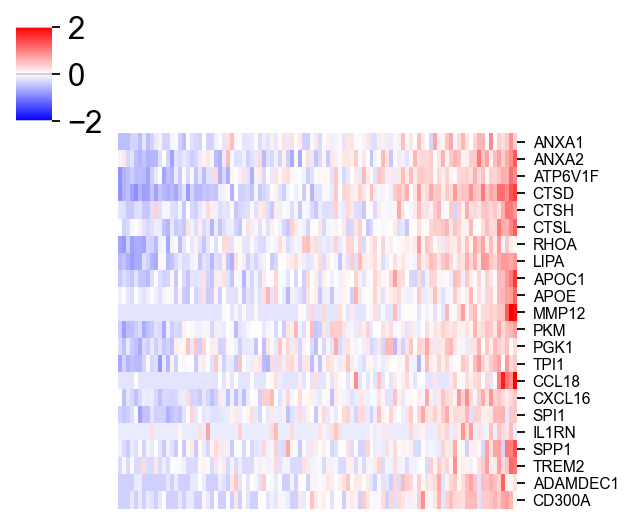

In [394]:
g = sns.clustermap(quantile_means, cmap='bwr', vmin=-2, vmax=2, center=0, col_cluster=False, row_cluster=False,
               xticklabels=False, yticklabels=True, figsize=(4.5,3.25))
g.ax_heatmap.grid(False)
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.tick_params(axis='y', labelsize=7) 
plt.savefig("figures/uveal_melanoma_scaled_manual.pdf")


In [354]:
gene_df[~gene_df.index.isin(new_up_and_corr_genes_human)].to_csv("uveal_melanoma_effero_genes.csv")

 # Shared dotplot

In [8]:
ipf_genedata = pd.read_csv("correlations_IPF_both.csv", index_col=0)

In [9]:
nsclc_genedata = pd.read_csv("intmacs_nsclc_both.csv", index_col=0)

In [10]:
als_genedata = pd.read_csv("correlations_ALS_both.csv", index_col=0)

In [11]:
uveal_genedata = pd.read_csv("uveal_melanoma_effero_genes.csv", index_col=0)

In [12]:
uveal_genedata = uveal_genedata.dropna(subset=['pearson_p'])
als_genedata = als_genedata.dropna(subset=['pearson_p_normal', 'pearson_p_ALS'])
nsclc_genedata = nsclc_genedata.dropna(subset=['pearson_p_normal', 'pearson_p_ipf'])
ipf_genedata = ipf_genedata.dropna(subset=['pearson_p_normal', 'pearson_p_ipf'])
uveal_genedata.pearson_p = fdrcorrection(uveal_genedata.pearson_p.values)[1]
als_genedata.pearson_p_normal = fdrcorrection(als_genedata.pearson_p_normal.values)[1]
als_genedata.pearson_p_ALS = fdrcorrection(als_genedata.pearson_p_ALS.values)[1]
nsclc_genedata.pearson_p_normal = fdrcorrection(nsclc_genedata.pearson_p_normal.values)[1]
nsclc_genedata.pearson_p_ipf = fdrcorrection(nsclc_genedata.pearson_p_ipf.values)[1]
ipf_genedata.pearson_p_normal = fdrcorrection(ipf_genedata.pearson_p_normal.values)[1]
ipf_genedata.pearson_p_ipf = fdrcorrection(ipf_genedata.pearson_p_ipf.values)[1]

In [21]:
uveal_genedata.loc[functional_genes].pearson_r.min()

0.0887656138714467

In [22]:
uveal_genedata.loc[functional_genes].pearson_p.max()

0.0020958501460170004

In [29]:
[print(x) for x in uveal_genedata[(uveal_genedata.pearson_p < 0.001) & (uveal_genedata.pearson_r > 0.25)].index]

FUCA1
LAPTM5
CTSS
S100A10
S100A11
FCER1G
CREG1
DBI
GPX1
HLA-C
HLA-B
HLA-DRB5
PLA2G7
ACTB
ATP6V1F
SAT1
TXN
CTSD
MMP12
SRGN
PSAP
LIPA
CD9
SDS
B2M
ANXA2
ATP6V0C
PFN1
GRN
TYROBP
PLD3


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [628]:
# Get the union of all gene indices
all_genes = (
    set(als_genedata.index)
    | set(ipf_genedata.index)
    | set(nsclc_genedata.index)
    | set(uveal_genedata.index)
)

In [629]:
unified_pearson_df = pd.DataFrame(
    index=sorted(all_genes),
    data={
        "ALS_normal_R": als_genedata.reindex(all_genes)["pearson_r_normal"] if "pearson_r_normal" in als_genedata else als_genedata.reindex(all_genes)["pearson_r"],
        "ALS_normal_p": als_genedata.reindex(all_genes)["pearson_p_normal"] if "pearson_p_normal" in als_genedata else als_genedata.reindex(all_genes)["pearson_p"],
        "ALS_disease_R": als_genedata.reindex(all_genes)["pearson_r_ALS"] if "pearson_r_ALS" in als_genedata else als_genedata.reindex(all_genes)["pearson_r"],
        "ALS_disease_p": als_genedata.reindex(all_genes)["pearson_p_ALS"] if "pearson_p_ALS" in als_genedata else als_genedata.reindex(all_genes)["pearson_p"],
        "IPF_normal_R": ipf_genedata.reindex(all_genes)["pearson_r_normal"] if "pearson_r_normal" in ipf_genedata else ipf_genedata.reindex(all_genes)["pearson_r"],
        "IPF_normal_p": ipf_genedata.reindex(all_genes)["pearson_p_normal"] if "pearson_p_normal" in ipf_genedata else ipf_genedata.reindex(all_genes)["pearson_p"],
        "IPF_disease_R": ipf_genedata.reindex(all_genes)["pearson_r_ipf"] if "pearson_r_ipf" in ipf_genedata else ipf_genedata.reindex(all_genes)["pearson_r"],
        "IPF_disease_p": ipf_genedata.reindex(all_genes)["pearson_p_ipf"] if "pearson_p_ipf" in ipf_genedata else ipf_genedata.reindex(all_genes)["pearson_p"],
        "NSCLC_normal_R": nsclc_genedata.reindex(all_genes)["pearson_r_normal"] if "pearson_r_normal" in nsclc_genedata else nsclc_genedata.reindex(all_genes)["pearson_r"],
        "NSCLC_normal_p": nsclc_genedata.reindex(all_genes)["pearson_p_normal"] if "pearson_p_normal" in nsclc_genedata else nsclc_genedata.reindex(all_genes)["pearson_p"],
        "NSCLC_disease_R": nsclc_genedata.reindex(all_genes)["pearson_r_ipf"] if "pearson_r_ipf" in nsclc_genedata else nsclc_genedata.reindex(all_genes)["pearson_r"],
        "NSCLC_disease_p": nsclc_genedata.reindex(all_genes)["pearson_p_ipf"] if "pearson_p_ipf" in nsclc_genedata else nsclc_genedata.reindex(all_genes)["pearson_p"],
        "UM_R": uveal_genedata.reindex(all_genes)["pearson_r"],
        "UM_p": uveal_genedata.reindex(all_genes)["pearson_p"],
    }
)


In [631]:
long_df = (
    unified_pearson_df
    .reset_index()
    .melt(id_vars='index', var_name='variable', value_name='value')
)

# Split variable into model, condition, and stat (R or p)
long_df[['model', 'condition', 'stat']] = long_df['variable'].str.extract(r'^(ALS|IPF|NSCLC|UM)_?(normal|disease)?_?(R|p)?$')


In [632]:
# Fix UM rows (UM_R, UM_p have no condition)
long_df.loc[long_df['model'] == 'UM', 'condition'] = 'disease'

# Pivot so each row is a gene/model/condition, with columns R and p
long_df = long_df.pivot_table(
    index=['index', 'model', 'condition'],
    columns='stat',
    values='value'
).reset_index()

# Calculate -log10(P)
long_df['minus_log10_p'] = -np.log10(long_df['p'])

# Rename columns for clarity
long_df = long_df.rename(columns={'index': 'gene', 'R': 'R', 'p': 'P', 'model': 'model', 'condition': 'condition'})

long_df


/home/orimosko/.local/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


stat,gene,model,condition,R,P,minus_log10_p
0,A1BG,ALS,disease,0.067707,2.595045e-15,14.585855
1,A1BG,ALS,normal,0.066729,5.606510e-05,4.251307
2,A1BG,IPF,disease,-0.031861,3.598145e-02,1.443921
3,A1BG,IPF,normal,0.003831,8.945557e-01,0.048393
4,A1BG,NSCLC,disease,0.050015,1.077465e-01,0.967597
...,...,...,...,...,...,...
108844,ZZZ3,UM,disease,0.035336,7.186361e-01,0.143491
108845,bP-21264C1.2,IPF,disease,0.007951,6.897742e-01,0.161293
108846,bP-21264C1.2,IPF,normal,0.030696,1.275008e-01,0.894487
108847,bP-21264C1.2,NSCLC,disease,0.005675,9.067120e-01,0.042531


In [644]:
long_df.loc[long_df.minus_log10_p.values > 9, 'minus_log10_p'] = 9

In [645]:
long_df[['model', 'condition']].value_counts()

model  condition
ALS    disease      20330
       normal       20330
IPF    disease      15971
       normal       15971
NSCLC  disease      13385
       normal       13385
UM     disease       9477
Name: count, dtype: int64

In [ ]:
selected_genes = ['TUBA1B',
 'LIPA',
 'CTSH',
 'TREM2',
 'APOE',
 'APOC1',
 'C1QC',
 'C1QB',
 'HLA-DRA',
 'HLA-DRB1',
 'CD74',
 'VEGFA',
 'VEGFB',
 'PDE8A',
 'HBEGF',
 'GRAMD1B',
 'DPP4',
 'ABCG1',
 'ERO1A',
 'CD58', 'ADTRP', 'CAT', 'CIR1', 'SLC27A3', #IPF
 'RXRA', 'BMP2K', 'CLEC4A', #NSCLC'
 'MMP12' # UM
]

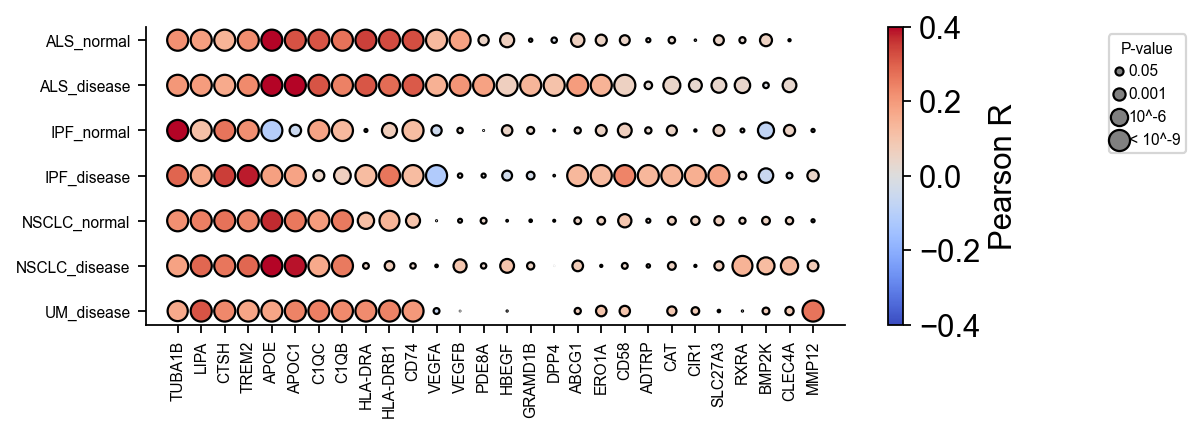

In [712]:
size_times = 10


plot_df = long_df[long_df['gene'].isin(selected_genes)].copy()

# Set categorical order for genes and models for consistent plotting
plot_df['gene'] = pd.Categorical(plot_df['gene'], categories=selected_genes, ordered=True)
model_order = ['ALS', 'IPF', 'NSCLC', 'UM']
condition_order = ['normal', 'disease']
plot_df['model'] = pd.Categorical(plot_df['model'], categories=model_order, ordered=True)
plot_df['condition'] = pd.Categorical(plot_df['condition'], categories=condition_order, ordered=True)

# Assign y positions for each (model, condition)
plot_df['y'] = plot_df['model'].astype(str) + "_" + plot_df['condition'].astype(str)
y_order = ['ALS_normal', 'ALS_disease',
           'IPF_normal', 'IPF_disease',
           'NSCLC_normal', 'NSCLC_disease', 'UM_disease']
plot_df['y'] = pd.Categorical(plot_df['y'], categories=y_order, ordered=True)

plt.figure(figsize=(len(selected_genes)*0.25, len(y_order)*0.35))
# Use categorical codes for x and y axes
x = plot_df['gene'].cat.codes
y = plot_df['y'].cat.codes

# Reverse the order of y_order and update plot_df['y'] accordingly
y_order = y_order[::-1]
plot_df['y'] = pd.Categorical(plot_df['y'], categories=y_order, ordered=True)
y = plot_df['y'].cat.codes

sc = plt.scatter(
    x=x,
    y=y,
    s=plot_df['minus_log10_p']*size_times,
    c=plot_df['R'],
    cmap='coolwarm',
    vmin=-0.4,
    vmax=0.4,
    edgecolor='k'
)

# Remove top and right axis spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(ticks=range(len(selected_genes)), labels=selected_genes, rotation=90, fontsize=7)
plt.yticks(ticks=range(len(y_order)), labels=y_order, fontsize=7)
plt.xlabel('')
plt.ylabel('')
plt.colorbar(sc, label='Pearson R')
#plt.tight_layout()
plt.grid(False)

# Add dot size legend
size_legend_p = [0.05, 1e-3, 1e-6, 1e-9]  # Example p-values for legend
size_legend = -np.log10(size_legend_p)
size_legend_labels = ["0.05", "0.001", "10^-6", "< 10^-9"]  # Corresponding labels for legend
size_legend_sizes = size_legend * size_times  
for size, label in zip(size_legend_sizes, size_legend_labels):
    plt.scatter([], [], s=size, c='gray', edgecolor='k', label=label)
plt.legend(title='P-value', loc='upper right', bbox_to_anchor=(1.5, 1), fontsize=7, title_fontsize=7)
plt.savefig("figures/per_disease_effero_correlations.pdf")
plt.show()


In [713]:
unified_pearson_df.to_excel("correlations_all_models.xlsx")